<a href="https://colab.research.google.com/github/Arya-code2005/Machine_Learning/blob/main/overfitting_and_underfitting_decisiontrees.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor

# 1. Create a random dataset (Noisy Sine Wave)
rng = np.random.RandomState(42)
X = np.sort(5 * rng.rand(80, 1), axis=0)
y = np.sin(X).ravel() + rng.normal(0, 0.2, X.shape[0])

# 2. Generate a dense grid of points so we can plot the tree's predictions smoothly
X_test = np.arange(0.0, 5.0, 0.01)[:, np.newaxis]

print(f"Dataset created with {X.shape[0]} samples.")

Dataset created with 80 samples.


In [2]:
# 1. Underfitted Tree (Max depth is too shallow)
underfit_tree = DecisionTreeRegressor(max_depth=2)
underfit_tree.fit(X, y)

# 2. Well-Fitted Tree (Balanced depth)
good_tree = DecisionTreeRegressor(max_depth=5)
good_tree.fit(X, y)

# 3. Overfitted Tree (No depth limit -> grows until pure)
overfit_tree = DecisionTreeRegressor() # max_depth=None by default
overfit_tree.fit(X, y)

# Predict on the test grid
y_under = underfit_tree.predict(X_test)
y_good = good_tree.predict(X_test)
y_over = overfit_tree.predict(X_test)

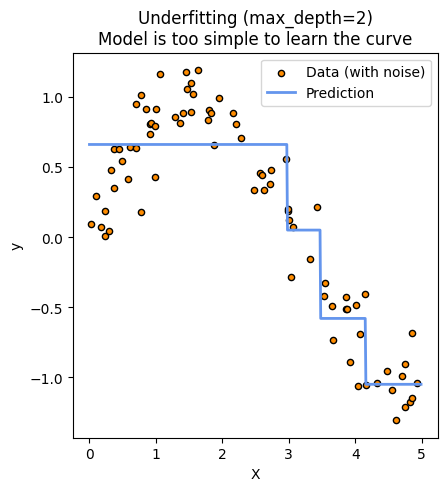

In [3]:
# Set up the plotting canvas
plt.figure(figsize=(16, 5))

# Plot 1: Underfitting
plt.subplot(1, 3, 1)
plt.scatter(X, y, s=20, edgecolor="black", c="darkorange", label="Data (with noise)")
plt.plot(X_test, y_under, color="cornflowerblue", label="Prediction", linewidth=2)
plt.title("Underfitting (max_depth=2)\nModel is too simple to learn the curve")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()


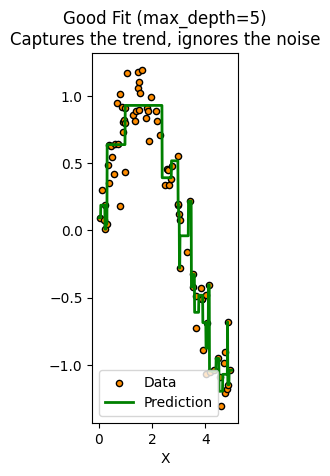

In [4]:
# Plot 2: Good Fit
plt.subplot(1, 3, 2)
plt.scatter(X, y, s=20, edgecolor="black", c="darkorange", label="Data")
plt.plot(X_test, y_good, color="green", label="Prediction", linewidth=2)
plt.title("Good Fit (max_depth=5)\nCaptures the trend, ignores the noise")
plt.xlabel("X")
plt.legend()


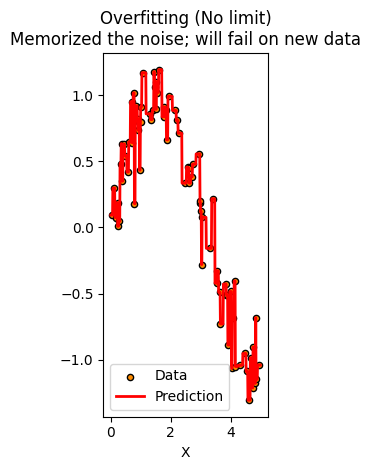

In [5]:
# Plot 3: Overfitting
plt.subplot(1, 3, 3)
plt.scatter(X, y, s=20, edgecolor="black", c="darkorange", label="Data")
plt.plot(X_test, y_over, color="red", label="Prediction", linewidth=2)
plt.title("Overfitting (No limit)\nMemorized the noise; will fail on new data")
plt.xlabel("X")
plt.legend()

plt.tight_layout()
plt.show()